# *Libraries*

In [53]:
from typing import TypedDict, Optional, List, Dict

import os

import fitz

import random

import chromadb

from docx import Document

from uuid import uuid4

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain.messages import SystemMessage, HumanMessage

from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display


# *LLM*

In [54]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# *Agent State*

In [55]:
class AgentState(TypedDict):

    # File
    file_path: Optional[str]
    file_name: Optional[str]
    file_type: Optional[str]

    # Validation
    validation_status: Optional[str]
    validation_reason: Optional[str]

    # Sections
    sections: List[Dict]

    # Chunks
    chunks : List[Dict]

    # Indexing stauts
    indexing_status : str

    # Suggested/Selected Topics or SubTopics
    selected_topic_or_subtopic : Optional[str]
    suggested_topics : Optional[str]

    # Reirieval Chunks
    retrieved_chunks: List[Dict]

    # Selected Questions type
    selected_questions_type : Optional[str]

    # Question History
    ques_history: List[Dict]

    # Total Score
    total_mcq_score: int
    total_theory_score: int

    

# *Upload API Node*

In [56]:
MAX_FILE_SIZE = 10

VALID_EXTENSION = [".pdf", ".txt", ".docx"]



In [57]:
def upload_api_node(state : AgentState) -> AgentState:
    """
    Validates uploaded document before entering RAG pipeline.

    Checks:
    - file existence
    - supported extension
    - file size limit

    Updates workflow state with validation results.
    """

    file_path = state["file_path"]
    
    # File Existence Check
    if not os.path.exists(file_path):

        state["validation_status"] = "failed"
        state["validation_reason"] = "file_not_found"

        return state
    
    # Retreive File Name and Extension
    file_name = os.path.basename(file_path)

    _, extension = os.path.splitext(file_name)

    # File Extensions Check
    if extension.lower() not in VALID_EXTENSION:

        state["validation_status"] = "failed"
        state["validation_reason"] = "unsupported_file_type"

        return state
    
    # File Size Check
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)

    if file_size_mb > MAX_FILE_SIZE:

        state["validation_status"] = "failed"
        state["validation_reason"] = "file_too_large"

        return state

    # Success 
    state["file_path"] = file_path
    state["file_name"] = file_name
    state["file_type"] = extension.lower()

    state["validation_status"] = "success"
    state["validation_reason"] = ""

    return state

# *Document Validation Node*

In [ ]:
def document_validation_node(state : AgentState) -> AgentState:
    """
    Validates whether uploaded document
    is safe and usable for the RAG pipeline.

    Checks:
    - corrupted PDF
    - encrypted PDF
    - extractable text
    - empty document
    - scanned/image-only PDF
    """

    # Reterive file info from state
    file_path = state["file_path"]
    file_type = state["file_type"]

    # Validates .txt and .docx files
    if file_type in [".txt", ".docx"]:

        state["validation_status"] = "success"
        
        return state
    
    # Validates PDF's
    # Corrupted pdf check
    try:
        # Open pdf
        doc = fitz.open(file_path)

    except Exception:
        state["validation_status"] = "failed"
        state["validation_reason"] = "corrupted_pdf"

        return state
    
    # Encrypted pdf check
    if doc.is_encrypted:
        state["validation_status"] = "failed"
        state["validation_reason"] = "encrypted_pdf"

        return state
    
    # Extract text
    extracted_text = ""

    for page in doc:
        extracted_text += page.get_text()

    # Empty pdf check
    if len(extracted_text.strip()) == 0:
        state["validation_status"] = "failed"
        state["validation_reason"] = "empty_pdf"

        return state  

    # Scanned/Image only pdf check
    if len(extracted_text.strip()) < 100:
        state["validation_status"] = "failed"
        state["validation_reason"] = "scanned_or_image_only_pdf"

        return state  
    
    # Success
    state["validation_status"] = "success"
    state["validation_reason"] = ""

    doc.close()

    return state    
    

# *Document Ingestion Node*

In [59]:
def document_ingestion_node(state : AgentState) -> AgentState:
    """
    Extract structured readable content 
    from validate document 

    strategy :-
    - for txt : full text extraction
    - for docx : pagragph based extraction
    - for pdf : page based extraction
    """

    # Retriving document info
    file_path = state["file_path"]
    file_type = state["file_type"]

    sections = []

    # txt text extraction
    if file_type == ".txt":

        with open(file_path, "r", encoding="utf-8") as file:
            
            text = file.read()

        sections.append({
            "page" : 1,
            "text" : text.strip()
        })

    # docx text extraction
    elif file_type == ".docx":

        doc = Document(file_path)

        full_text = ""

        for paragraph in doc.paragraphs:
            
            if paragraph.text.strip():

                full_text += paragraph.text + "\n"

        sections.append({
            "page" : 1,
            "text" : full_text.strip()
        })

    # pdf text extraction
    elif file_type == ".pdf":
        doc = fitz.open(file_path)
 
        for page_number, page in enumerate(doc):
            text = page.get_text()

            if len(text.strip()) == 0:
                continue
        
            sections.append({
                "page" : page_number + 1,
                "text" : text.strip()
            })
            
        doc.close()

    # Store Sections in state
    state["sections"] = sections
    
    return state

        

# *Semantic Chunking Node*

In [60]:
def semantic_chunking_node(state : AgentState) -> AgentState:
    """
    Converts extracted documetn setions 
    into semantically meaningful chunks.

    Strategy:
    - Recursive semantic splitting
    - Overlap preservation
    - Page tracking
    """

    # Reterive sections info from state
    sections = state["sections"]

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size = 800,
        chunk_overlap = 150,
        length_function = len
    )

    chunks = []

    for section in sections:

        page = section["page"]
        text = section["text"]

        # Skip empty text 
        if len(text.strip()) == 0:
            continue

        # Generate semantic chunks
        split_chunks = text_splitter.split_text(text)

        # Store chunks meta data
        for chunk_order, chunk_text in enumerate(split_chunks):
            chunks.append({
                "chunk_id" : str(uuid4()),
                "page" : page,
                "chunk_order" : chunk_order + 1,
                "text" : chunk_text
            })

    state["chunks"] = chunks

    return state
        

# *Indexing Node*

In [ ]:
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

chroma_client = chromadb.PersistentClient(path = "./chroma_db")

collection = chroma_client.get_or_create_collection(name="educational_chunks")

def indexing_node(state : AgentState) -> AgentState:
    """
    Converts chunks into embeddings 
    and store them in chromadb.
    """

    chunks = state["chunks"]
    
    # Process each chunk
    for chunk in chunks:

        # Reterive info from chunks
        chunk_id = chunk["chunk_id"]
        page = chunk["page"]
        text = chunk["text"]
        chunk_order = chunk["chunk_order"]

        # Generate embeddings
        response = llm.embeddings.create(
            model = "text-embedding-3-small",
            input = text
        )

        embedding = embedding_model.embed_query(text)

        # Store in ChromaDB
        collection.add(
            ids = [chunk_id],
            documents = [text],
            embeddings = [embedding],
            metadatas = [{
                "page" : page,
                "chunk_order" : chunk_order
            }]

        )

    # Store Indexing status
    state["indexing_status"] = "success"

    return state

# *Topic/SubTopic Suggestions and Selection Node*

In [ ]:
def topic_suggestion_selection_node(state: AgentState) -> AgentState:
    """
    Generates topic/subtopic names
    from educational material and
    lets user select topic/subtopic.

    Strategies:
    - Random chunk sampling
    - LLM-based topic extraction
    """

    chunks = state["chunks"]

    combined_text = ""

    # Random chunk sampling
    sample_chunks = random.sample(chunks, min(15, len(chunks)))

    for chunk in sample_chunks:

        combined_text += chunk["text"] + "\n\n"

    response = llm.invoke([
        SystemMessage(
            content="""
            You are an educational topic extractor.

            Extract major topics and subtopics
            from provided educational content.
            """
        ),

        HumanMessage(
            content=combined_text
        )
    ])

    # Extract generated topics
    suggested_topics = response.content

    # Store in state
    state["suggested_topics"] = suggested_topics

    return state

# *Retrieval Node*

In [63]:
def retrieval_node(state : AgentState) -> AgentState:
    """
    Retrieves semantically relevant chunks
    based on selected topic/subtopic.
    """

    # Retrieve selected topic/subtopic
    retrieval_query = state["selected_topic_or_subtopic"] 

    # Generate query embedding
    embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

    query_embedding = embedding_model.embed_query(retrieval_query)
    
    # Search ChromaDB
    results = collection.query(query_embeddings = [query_embedding],  n_results=5)

    # Extract retrieved chunks
    retrieved_chunks = []

    documents = results["documents"][0]

    metadatas = results["metadatas"][0]

    ids = results["ids"][0]

    # Build retrieved chunk objects
    for chunk_id, text, metadata in zip(ids, documents, metadatas):

        retrieved_chunks.append({

            "chunk_id": chunk_id,

            "text": text,

            "page": metadata["page"],

            "chunk_order":
            metadata["chunk_order"]
        })

    # Store in state
    state["retrieved_chunks"] = retrieved_chunks

    return state

# *MCQ's and Theory Type Questions Selections Node*

In [64]:
def select_mcq_or_theory_ques_node(state : AgentState) -> AgentState:
    """
    Take user input for selecting 
    question generation type.
    """

    # Display Questions type
    print("Select questions type:")
    print("1. MCQ Questions")
    print("2. Theory Questions")

    # Input Validation loop
    while True:

        user_input = input("Enter questions type(1 or 2): ")

        if user_input in ["1", "2"]:
            break

        print("Invalid input. Please Enter 1 or 2.")

    # Store selected question type in state
    if user_input == "1":
        state["selected_questions_type"] = "mcq"
    else: 
        state["selected_questions_type"] = "theory"

    return state

# *MCQ's or Theory Questions Generation Node*

In [65]:
def mcq_or_theory_ques_gen_node(state : AgentState) -> AgentState:
    """
    Generates MCQ or Theory questions
    in a continuous interactive loop.

    Stores: 
    - generated question
    - hidden correct answers
    - user answer
    - question history
    """

    # Retrieve workflow state
    topic = state["selected_topic_or_subtopic"]

    topic_chunks = state["retrieved_chunks"]

    ques_type = state["selected_questions_type"]

    # Build context
    context = ""

    for chunk in topic_chunks:
        context += chunk["text"] + "\n\n"

    # Ask user for questions difficulty 
    print("Questions difficutly Options: ")
    print("1. Easy")
    print("2. Medium")
    print("3. Hard")

    difficulty_map = {
        "1" : "easy",
        "2" : "medium",
        "3" : "hard"
    }

    while True:

        difficulty_input = input("Select difficulty (1/2/3): ")

        if difficulty_input in difficulty_map:
            break
            
        print("Invalid difficulty selection. Choice from (1/2/3).")

    ques_difficulty = difficulty_map[difficulty_input]

    # Session memory 
    ques_history = state.get("ques_history", [])

    # Interactive question loop
    count = 0

    user_input = ""

    while user_input.lower() != "exit" and count < 5:

        count += 1

        # Previous question memory 
        previous_ques = ""

        for item in ques_history:
            previous_ques += item["question"] + "\n"

        # MCQ generation
        if ques_type == "mcq":

            system_mess = SystemMessage(
                content=f"""
                        You are a educational MCQ generator.

                        Generate one mcq question.

                        Educational context:
                        {context}

                        Topic:
                        {topic}

                        Difficulty:
                        {ques_difficulty}                        

                        Previously generated questions:
                        {previous_ques}

                        Rules:
                        - Generate only one mcq
                        - Generate exactly four options
                        - Do not repeat previous questions
                        - Include correct answer
                        - Keep formatting clean

                        Output Format:

                        Question: ...

                        A) ...
                        B) ...
                        C) ...
                        D) ...

                        Correct Answer: A
                        """
            )

            response = llm.invoke([system_mess])

            generated_output = response.content

            # Extract correct answer
            mcq_ans = generated_output.split("Correct Answer:")[-1].strip().lower()

            # Remove answer from display
            display_ques = generated_output.split("Correct Answer:")[0].strip()

            print("Generated MCQ")
            print(display_ques)

            # User answer input
            while True:

                user_input = input("Enter answer (a/b/c/d) or type 'exit': ")

                if user_input.lower() in ["a", "b", "c", "d", "exit"]:
                    break

                print("Invalid answer options. Choice options from (a/b/c/d).")
            

        # Theory question generation
        else:

            system_message = SystemMessage(

                content=f"""
                You are an educational theory
                question generator.

                Generate one theory question.

                Educational Context:
                {context}

                Topic:
                {topic}

                Difficulty:
                {ques_difficulty}

                Previously Generated Questions:
                {previous_ques}

                Rules:
                - Generate only one theory question
                - Do not repeat previous questions
                - Generate ideal answer
                - Ideal answer should be
                  around 50-100 words

                Output Format:

                Question: ...

                Ideal Answer: ...
                """
            )

            response = llm.invoke([system_message])

            generated_output = response.content

            # Extract Hidden Ideal Answer
            theory_ans = generated_output.split("Ideal Answer:")[-1].strip()
        
            # Remove Answer From Display
            display_ques = generated_output.split("Ideal Answer:")[0].strip()
            

            print("Generated Theory Question: ")

            print(display_ques)

            # User Answer Input
            while True:

                user_input = input("Enter answer or type 'exit': ")
                
                if user_input.lower() == "exit" or 50 <= len(user_input.split()) <= 100:
                    break

                print("Answer should contain approximately 50-100 words.")

        # Store Session History
        if user_input.lower() != "exit":

            qa_item = {

                "question": display_ques,

                "user_answer": user_input,

                "difficulty": ques_difficulty,

                "question_type": ques_type
            }

            # MCQ-specific storage
            if ques_type == "mcq":

                qa_item["mcq_answer"] = mcq_ans


            # Theory-specific storage
            else:

                qa_item["theory_answer"] = theory_ans
                

            ques_history.append(qa_item)


    # Store Session History In State
    state["ques_history"] = ques_history

    return state

# *Evaluation Node*

In [66]:
def evaluation_node(state : AgentState) -> AgentState:
    """
    Evaluates user answers 

    Strategy for mcq's:
    - give marks 1(correct) or 0(wrong)
    - show correct answer

    Strategy for theory ques: 
    - give marks from 0 to 10
    - use llm for evaluation
    - shows correct answes 
    """


    # Retrieve workflow state
    ques_history = state["ques_history"]

    # Total Score
    total_mcq_score = 0 
    total_theory_score = 0
    
    for question in ques_history:

        # MCQ's evaluations
        if question["question_type"] == "mcq":

            if question["mcq_answer"].lower().strip() == question["user_answer"].lower().strip():

                mcq_score = 1
            
            else:
                mcq_score = 0
     
            question["mcq_score"] = mcq_score
            
            total_mcq_score += mcq_score

            # Display result
            print(f"""
Questions: 
{question["question"]}

Score:
{question["mcq_score"]}

Your Answer:
{question["user_answer"]}

Correct Answer:
{question["mcq_answer"]}
""")

        # Theory questions evaluation
        else:

            system_mess = SystemMessage(
                content=f"""
                You are theory question evaluator.

                Give each question score from 0 to 10.

                Question:
                {question["question"]}

                Difficulty:
                {question["difficulty"]}

                User answer:
                {question["user_answer"]}

                Actual answer:
                {question["theory_answer"]}

                Output format:

                Score : ...
            """
            )

            response = llm.invoke([system_mess])

            gen_output = response.content

            theory_score = gen_output.split("Score:")[-1].strip()

            question["theory_score"] = theory_score

            try:

                total_theory_score += int(theory_score)

            except:

                pass
            
            # Display reuslt
            print(f"""
Questions: 
{question["question"]}

Score:
{question["theory_score"]}/10

Your Answer:
{question["user_answer"]}

Correct Answer:
{question["theory_answer"]}
""")


    state["total_mcq_score"] = total_mcq_score
    state["total_theory_score"] = total_theory_score

    return state            
    


# *Graph Creation*

In [67]:
graph = StateGraph(AgentState)

graph.add_node("upload_api_node", upload_api_node)
graph.add_node("document_validation_node", document_validation_node)
graph.add_node("document_ingestion_node", document_ingestion_node)
graph.add_node("semantic_chunking_node", semantic_chunking_node)
graph.add_node("indexing_node", indexing_node)
graph.add_node("topic_suggestion_selection_node", topic_suggestion_selection_node)
graph.add_node("retrieval_node", retrieval_node)
graph.add_node("select_mcq_or_theory_ques_node", select_mcq_or_theory_ques_node)
graph.add_node("mcq_or_theory_ques_gen", mcq_or_theory_ques_gen_node)
graph.add_node("evaluation_node", evaluation_node)


graph.add_edge(START, "upload_api_node")
graph.add_edge("upload_api_node", "document_validation_node")
graph.add_edge("document_validation_node", "document_ingestion_node")
graph.add_edge("document_ingestion_node", "semantic_chunking_node")
graph.add_edge("semantic_chunking_node", "indexing_node")
graph.add_edge("indexing_node", "topic_suggestion_selection_node")
graph.add_edge("topic_suggestion_selection_node", "retrieval_node")
graph.add_edge("retrieval_node", "select_mcq_or_theory_ques_node")
graph.add_edge("select_mcq_or_theory_ques_node", "mcq_or_theory_ques_gen")
graph.add_edge("mcq_or_theory_ques_gen", "evaluation_node")
graph.add_edge("evaluation_node", END)


agent = graph.compile()

# *Graph Visulization*

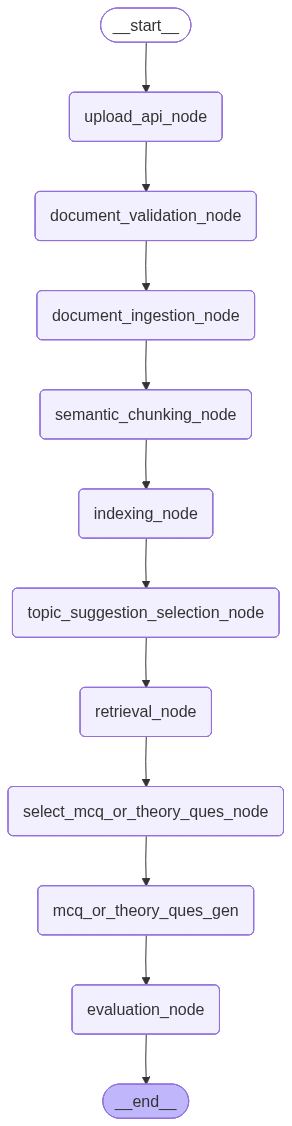

In [68]:
display(Image(agent.get_graph().draw_mermaid_png()))